### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Excel File

In [6]:
file = 'F:/Downloads/Customer_Churn_Data_Large.xlsx'

demographics = pd.read_excel(file, sheet_name = 'Customer_Demographics')
transactions = pd.read_excel(file, sheet_name = 'Transaction_History')
service = pd.read_excel(file, sheet_name = 'Customer_Service')
online = pd.read_excel(file, sheet_name = 'Online_Activity')
churn = pd.read_excel(file, sheet_name = 'Churn_Status')

In [9]:
demographics.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [8]:
transactions.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


### Merge All Data

Merge Using CustomerID

In [10]:
df = demographics.merge(online, on = 'CustomerID')
df = df.merge(churn, on = 'CustomerID')

Check the new merge df sheet

In [11]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,2023-12-05,5,Website,1
2,3,18,M,Single,Low,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,2023-10-27,41,Website,0


Aggregate Transactions

In [13]:
txn_summary = transactions.groupby('CustomerID')['AmountSpent'].sum().reset_index()
txn_summary.rename(columns = {'AmountSpent':'TotalSpent'}, inplace = True)

df = df.merge(txn_summary, on = 'CustomerID')

In [14]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,TotalSpent
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,0,416.50
1,2,65,M,Married,Low,2023-12-05,5,Website,1,1547.42
2,3,18,M,Single,Low,2023-11-15,3,Website,0,1702.98
3,4,21,M,Widowed,Low,2023-08-25,2,Website,0,917.29
4,5,21,M,Divorced,Medium,2023-10-27,41,Website,0,2001.49


Aggregate Service Interactions

In [15]:
service_count = service.groupby('CustomerID')['InteractionID'].count().reset_index()
service_count.rename(columns = {'InteractionID':'ServiceInteractions'}, inplace = True)

df = df.merge(service_count, on = 'CustomerID')

In [16]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,TotalSpent,ServiceInteractions
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,0,416.50,1
1,2,65,M,Married,Low,2023-12-05,5,Website,1,1547.42,1
2,3,18,M,Single,Low,2023-11-15,3,Website,0,1702.98,1
3,4,21,M,Widowed,Low,2023-08-25,2,Website,0,917.29,2
4,6,57,F,Divorced,Medium,2023-09-17,2,Website,0,1164.29,1


### Basic Data Check (EDA)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668 entries, 0 to 667
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           668 non-null    int64         
 1   Age                  668 non-null    int64         
 2   Gender               668 non-null    object        
 3   MaritalStatus        668 non-null    object        
 4   IncomeLevel          668 non-null    object        
 5   LastLoginDate        668 non-null    datetime64[ns]
 6   LoginFrequency       668 non-null    int64         
 7   ServiceUsage         668 non-null    object        
 8   ChurnStatus          668 non-null    int64         
 9   TotalSpent           668 non-null    float64       
 10  ServiceInteractions  668 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(4)
memory usage: 57.5+ KB


In [18]:
df.describe()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,TotalSpent,ServiceInteractions
count,668.000000,668.000000,668,668.00000,668.000000,668.000000,668.000000
mean,488.525449,43.023952,2023-07-03 16:03:35.568862208,26.16018,0.214072,1312.423698,1.500000
min,1.000000,18.000000,2023-01-01 00:00:00,1.00000,0.000000,9.800000,1.000000
25%,245.500000,29.000000,2023-04-01 00:00:00,14.00000,0.000000,686.600000,1.000000
50%,482.500000,43.000000,2023-07-08 00:00:00,28.00000,0.000000,1271.805000,1.500000
75%,736.250000,56.000000,2023-09-29 00:00:00,38.00000,0.000000,1882.330000,2.000000
max,995.000000,69.000000,2023-12-31 00:00:00,49.00000,1.000000,3386.040000,2.000000
std,286.258380,15.400287,NaN,14.12229,0.410484,750.336283,0.500375


In [19]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
TotalSpent             0
ServiceInteractions    0
dtype: int64

### Visualization (EDA)

1 Histrogram

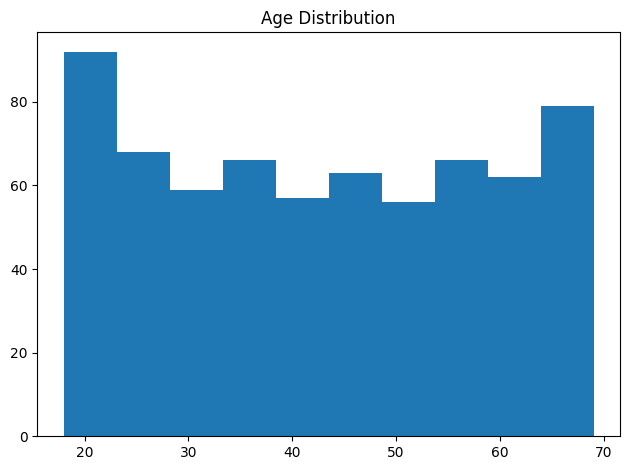

In [20]:
plt.hist(df['Age'])
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

2 Boxplot

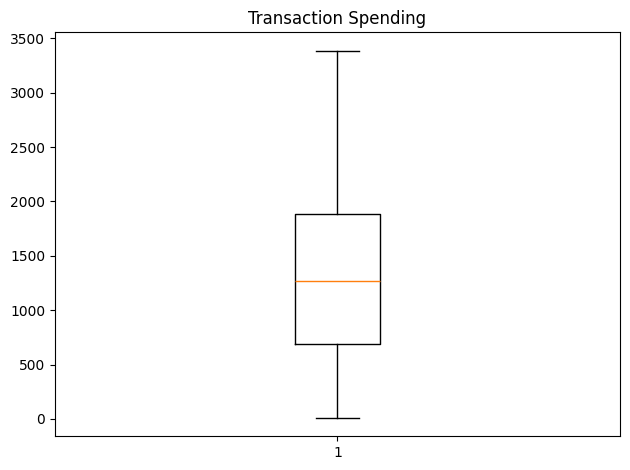

In [21]:
plt.boxplot(x = df['TotalSpent'])
plt.title('Transaction Spending')
plt.tight_layout()
plt.show()

3 Churn Distribution

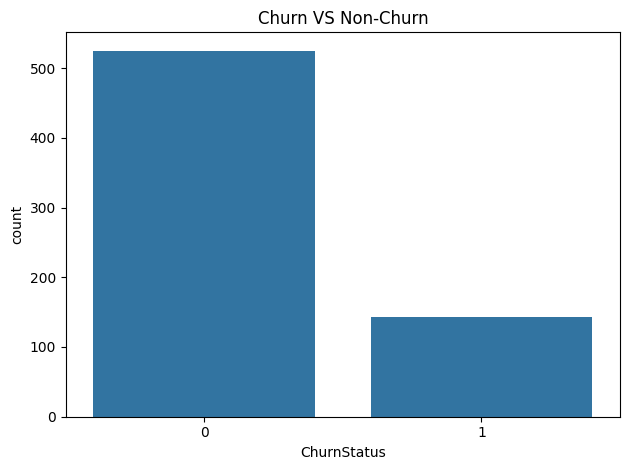

In [22]:
sns.countplot(x = 'ChurnStatus', data = df)
plt.title('Churn VS Non-Churn')
plt.tight_layout()
plt.show()

4 Scatter Plot

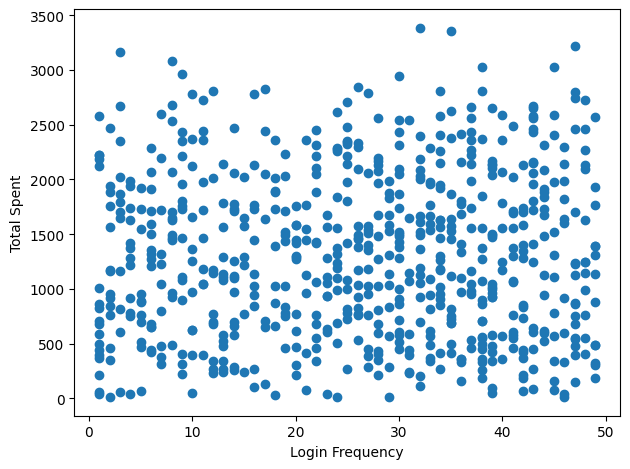

In [23]:
plt.scatter(df['LoginFrequency'], df['TotalSpent'])
plt.xlabel('Login Frequency')
plt.ylabel('Total Spent')
plt.tight_layout()
plt.show()

### Handle Missing Values

Check Missing Values

In [24]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
TotalSpent             0
ServiceInteractions    0
dtype: int64

Full Numeric Values

In [25]:
df['TotalSpent'].fillna(df['TotalSpent'].mean(), inplace = True)

Fill Categorical

In [26]:
df['Gender'].fillna('Unknown', inplace = True)

### Handle Outlier

Using IQR Method

In [29]:
Q1 = df['TotalSpent'].quantile(0.25)
Q3 = df['TotalSpent'].quantile(0.75)

IQR = Q3 - Q1

df = df[(df['TotalSpent'] >= Q1 - 1.5 * IQR) & (df['TotalSpent'] <= Q3 + 1.5 * IQR)]

### Encode Categorical Data

Convert tect to number

In [32]:
df = pd.get_dummies(df, columns = ['Gender','MaritalStatus','IncomeLevel','ServiceUsage'])

In [33]:
df.head()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,TotalSpent,ServiceInteractions,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_High,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Mobile App,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,62,2023-10-21,34,0,416.50,1,False,True,False,False,True,False,False,True,False,True,False,False
1,2,65,2023-12-05,5,1,1547.42,1,False,True,False,True,False,False,False,True,False,False,False,True
2,3,18,2023-11-15,3,0,1702.98,1,False,True,False,False,True,False,False,True,False,False,False,True
3,4,21,2023-08-25,2,0,917.29,2,False,True,False,False,False,True,False,True,False,False,False,True
4,6,57,2023-09-17,2,0,1164.29,1,True,False,True,False,False,False,False,False,True,False,False,True


### Normalize Data

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Age','TotalSpent','LoginFrequency']] = scaler.fit_transform(df[['Age','TotalSpent','LoginFrequency']])

### Final DataSet

In [35]:
df.to_csv('Cleaned_churn_Data.csv', index = False)

In [36]:
df.head()

,CustomerID,Age,LastLoginDate,LoginFrequency,ChurnStatus,TotalSpent,ServiceInteractions,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_High,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Mobile App,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,1.233111,2023-10-21,0.555554,0,-1.194924,1,False,True,False,False,True,False,False,True,False,True,False,False
1,2,1.428059,2023-12-05,-1.499476,1,0.313423,1,False,True,False,True,False,False,False,True,False,False,False,True
2,3,-1.626119,2023-11-15,-1.641202,0,0.520898,1,False,True,False,False,True,False,False,True,False,False,False,True
3,4,-1.431172,2023-08-25,-1.712065,0,-0.527003,2,False,True,False,False,False,True,False,True,False,False,False,True
4,6,0.908199,2023-09-17,-1.712065,0,-0.197571,1,True,False,True,False,False,False,False,False,True,False,False,True


In [37]:
import os
os.listdir()

['.conda',
 '.condarc',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.spyder-py3',
 '.vscode',
 '3D Objects',
 'AppData',
 'Application Data',
 'Blinkit_data_analysis_python.ipynb',
 'Cleaned_churn_Data.csv',
 'Contacts',
 'Cookies',
 'Favorites',
 'IntelGraphicsProfiles',
 'Links',
 'lloyds_project.ipynb',
 'Local Settings',
 'matplotlib_histrogram.png',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'OneDrive - University of Essex',
 'Pictures',
 'PrintHood',
 'PyCharm 2025.3.1',
 'PycharmProjects',
 'Recent',
 'Saved Games',
 'ScStore',
 'Searches',
 'SendTo',
 'shubham.txt',
 'Start Me